# Projeto M1.2 - Melhoria de radiografias do MURA

**Disciplina:** Processamento de Imagens  
**Integrantes:** Hanry Ledoux Krobel Lorenz; João Victor Serpa; Kauan Fernandes Gonçalves.

Este notebook implementa um pipeline próprio de melhoria de imagens médicas usando somente Python, NumPy e PIL para leitura. As operações centrais - transformação de intensidade, geração de ruído, convolução, filtro da mediana, filtro Gaussiano, unsharp masking e high-boost - são implementadas manualmente, sem chamadas a `cv2.filter2D`, `cv2.medianBlur`, `cv2.equalizeHist`, `scipy.ndimage` ou funções prontas equivalentes.

> **Como executar:** no Google Colab, use **Ambiente de execução > Executar tudo**. O notebook baixa somente as três amostras usadas no experimento; não é necessário baixar o arquivo completo do MURA.


## 1. Enunciado atendido

O trabalho pede um pipeline de processamento para três radiografias de uma mesma região anatômica do conjunto MURA, contendo:

1. seleção e justificativa das imagens;
2. caracterização inicial dos problemas visuais;
3. inserção de ruído artificial controlado;
4. uma transformação pontual de intensidade;
5. suavização espacial;
6. aguçamento que preserve a imagem completa, e não apenas bordas isoladas;
7. uma segunda configuração do pipeline;
8. comparação visual e quantitativa com duas métricas;
9. discussão do melhor resultado e das limitações.

As duas configurações usam a mesma imagem degradada e a mesma correção gama. A comparação altera a suavização e o aguçamento: a configuração A usa mediana + unsharp masking, enquanto a configuração B usa Gaussiano + high-boost.


## 2. Contexto e escolha da aplicação

Radiografias musculoesqueléticas podem apresentar baixo contraste, regiões pouco definidas e ruídos que dificultam tanto a inspeção humana quanto uma etapa posterior de análise automática. O objetivo aqui é estudar o compromisso entre remover interferências e preservar estruturas ósseas.

Foi escolhida a categoria **XR_SHOULDER** (ombro) do MURA. As três imagens foram selecionadas entre amostras do início do conjunto de treino disponibilizado por um espelho público do MURA, nos índices 0, 4 e 7. Elas mostram a mesma região anatômica, mas têm enquadramentos, intensidade média e definição estrutural diferentes:

- a amostra 1 é mais escura e apresenta baixo contraste;
- a amostra 2 tem uma estrutura óssea mais clara e maior variação de tons;
- a amostra 3 possui mais área anatômica e transições suaves, permitindo observar o efeito do aguçamento.

Fonte original do conjunto: [MURA - Stanford ML Group](https://stanfordmlgroup.github.io/competitions/mura/).  
Fonte das amostras usadas no notebook: [espelho MURA no Hugging Face](https://huggingface.co/datasets/KhalfounMehdi/MURA).

Conferência com o trabalho anterior anexado: o notebook M1.1 usa imagens gerais da pasta `ImgTrabM1` (como `lena.jpg`, `cameraman.png` e `contrast.jpg`), e não uma categoria anatômica do MURA. Portanto, `XR_SHOULDER` representa uma categoria nova em relação ao material anterior.

Os rótulos retornados pelo conjunto são apenas metadados de normalidade/anormalidade e não são usados para diagnóstico. O experimento avalia qualidade de imagem, não interpretação clínica.


In [3]:
# Bibliotecas permitidas para leitura, cálculo e visualização.
import io       # Manipulação de dados em memória.
import json     # Leitura e manipulação de dados no formato JSON.
import math     # Operações matemáticas.
import time     # Controle de tempo e pausas na execução.
from urllib.request import Request, urlopen  # Acesso a dados pela internet.

import numpy as np              # Cálculos numéricos e manipulação de matrizes.
import matplotlib.pyplot as plt # Criação e exibição de gráficos e imagens.
from PIL import Image           # Abertura e processamento de imagens.

# Define a resolução padrão das figuras para 110 DPI.
plt.rcParams["figure.dpi"] = 110

# Define o mapa de cores padrão das imagens como escala de cinza.
plt.rcParams["image.cmap"] = "gray"

# Link para a página do conjunto de dados MURA no Hugging Face.
DATASET_CARD = "https://huggingface.co/datasets/KhalfounMehdi/MURA"

# Endereço da API utilizada para consultar as amostras do conjunto de dados.
DATASET_VIEWER = "https://datasets-server.huggingface.co/rows"

# Define a região anatômica selecionada: ombro (Shoulder).
ANATOMICAL_REGION = "XR_SHOULDER"

# Lista dos índices das amostras que serão utilizadas no processamento.
SELECTED_ROWS = [0, 4, 7]

# Define a quantidade de ruído sal e pimenta aplicada às imagens.
# 0.03 representa 3% dos pixels que receberão ruído.
NOISE_AMOUNT = 0.03

# Define a semente aleatória para que o ruído seja reproduzido
# da mesma forma em diferentes execuções.
NOISE_SEED = 2026

# Define o valor de gama utilizado para ajustar o brilho das imagens.
# Um valor de 0.95 proporciona um clareamento moderado.
GAMMA_VALUE = 0.95

# Exibe no terminal a região anatômica selecionada.
print("Região selecionada:", ANATOMICAL_REGION)

# Exibe no terminal os índices das amostras escolhidas.
print("Índices das amostras:", SELECTED_ROWS)

# Exibe a quantidade de ruído em formato percentual e a semente utilizada.
print("Ruído sal-e-pimenta: {:.1%}; semente: {}".format(NOISE_AMOUNT, NOISE_SEED))

Região selecionada: XR_SHOULDER
Índices das amostras: [0, 4, 7]
Ruído sal-e-pimenta: 3.0%; semente: 2026


In [4]:
def fetch_json(url):
    # Busca dados JSON através de uma URL.
    # Utiliza um cabeçalho para facilitar a aceitação da requisição pelo servidor.
    request = Request(url, headers={"User-Agent": "Mozilla/5.0"})

    # Abre a URL com tempo limite de 60 segundos e carrega o JSON retornado.
    with urlopen(request, timeout=60) as response:
        return json.load(response)


def download_mura_samples(row_indices):
    # Baixa somente as amostras selecionadas do conjunto de dados MURA.
    # Recebe uma lista contendo os índices das linhas desejadas.

    # Identifica o maior índice para definir a quantidade de linhas consultadas.
    highest_row = max(row_indices)

    # Monta a URL de consulta à API do Hugging Face.
    # Solicita as linhas do conjunto de treinamento desde o índice 0.
    query = (
        f"{DATASET_VIEWER}?dataset=KhalfounMehdi%2FMURA&config=default"
        f"&split=train&offset=0&length={highest_row + 1}"
    )

    # Realiza a consulta e armazena o resultado em formato JSON.
    payload = fetch_json(query)

    # Cria um dicionário relacionando o índice de cada linha aos seus dados.
    rows_by_index = {item["row_idx"]: item["row"] for item in payload["rows"]}

    # Cria um dicionário vazio para armazenar as amostras selecionadas.
    samples = {}

    # Percorre cada índice solicitado pelo usuário.
    for row_index in row_indices:

        # Verifica se o índice existe nos dados retornados pelo servidor.
        if row_index not in rows_by_index:
            raise ValueError(f"Amostra {row_index} não foi encontrada no servidor.")

        # Recupera os dados da linha correspondente ao índice atual.
        row = rows_by_index[row_index]

        # Obtém o endereço da imagem armazenado nos dados da amostra.
        image_url = row["image"]["src"]

        # Cria uma requisição para baixar a imagem utilizando um cabeçalho.
        request = Request(image_url, headers={"User-Agent": "Mozilla/5.0"})

        # Abre a URL da imagem com tempo limite de 60 segundos.
        with urlopen(request, timeout=60) as response:

            # Lê os bytes da imagem baixada.
            image_bytes = response.read()

        # Abre a imagem a partir dos bytes armazenados em memória.
        # Converte a imagem para o modo "L", representando escala de cinza.
        image = Image.open(io.BytesIO(image_bytes)).convert("L")

        # Armazena os dados da amostra no dicionário.
        samples[row_index] = {

            # Converte a imagem em uma matriz NumPy de inteiros sem sinal de 8 bits.
            "image": np.array(image, dtype=np.uint8),

            # Armazena o rótulo da imagem como um número inteiro.
            "label": int(row["label"]),

            # Armazena a largura da imagem em pixels.
            "width": int(row["image"]["width"]),

            # Armazena a altura da imagem em pixels.
            "height": int(row["image"]["height"]),

            # Guarda a URL de origem da imagem.
            "source_url": image_url,
        }

    # Retorna o dicionário contendo todas as amostras selecionadas.
    return samples


# Executa a função de download utilizando os índices definidos anteriormente.
samples = download_mura_samples(SELECTED_ROWS)

# Percorre os índices das amostras selecionadas para exibir suas informações.
for row_index in SELECTED_ROWS:

    # Recupera os dados da amostra atual.
    sample = samples[row_index]

    # Exibe a resolução da imagem e seu rótulo no conjunto de dados.
    print(
        f"linha {row_index}: {sample['width']}x{sample['height']} pixels; "
        f"rótulo do conjunto={sample['label']}"
    )

linha 0: 380x512 pixels; rótulo do conjunto=1
linha 4: 440x512 pixels; rótulo do conjunto=1
linha 7: 501x512 pixels; rótulo do conjunto=1


### Caracterização inicial

A tabela a seguir registra medidas simples antes do processamento. O desvio-padrão é usado como indicador de espalhamento dos tons; ele não substitui uma avaliação clínica, mas ajuda a comparar as imagens de forma objetiva.


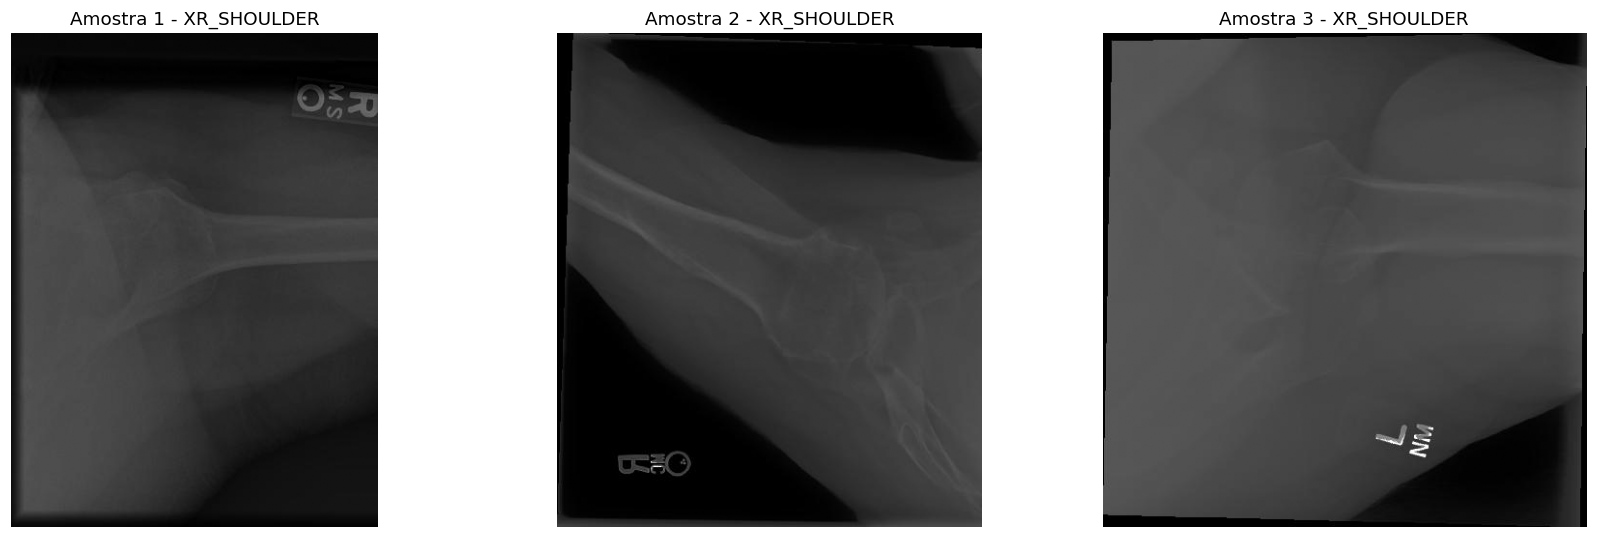

,altura,largura,mínimo,máximo,média,desvio padrão,p01,mediana,p99
Amostra 1 - XR_SHOULDER,512,380,0,116,46.87,23.59,1.0,52.0,80.0
Amostra 2 - XR_SHOULDER,512,440,0,255,38.67,28.56,0.0,51.0,78.0
Amostra 3 - XR_SHOULDER,512,501,0,255,66.81,23.93,0.0,74.0,88.0


In [5]:
def image_statistics(image):
    # Calcula estatísticas descritivas da imagem sem alterar seus dados.
    # Recebe a imagem como uma matriz de pixels.

    # Converte os valores dos pixels para float64,
    # garantindo maior precisão nos cálculos estatísticos.
    values = image.astype(np.float64)

    # Retorna um dicionário contendo as estatísticas da imagem.
    return {
        # Obtém a altura da imagem em pixels.
        "altura": image.shape[0],

        # Obtém a largura da imagem em pixels.
        "largura": image.shape[1],

        # Identifica o menor valor de intensidade dos pixels.
        "mínimo": int(image.min()),

        # Identifica o maior valor de intensidade dos pixels.
        "máximo": int(image.max()),

        # Calcula a média dos valores de intensidade.
        "média": float(values.mean()),

        # Calcula o desvio padrão dos valores dos pixels.
        "desvio padrão": float(values.std()),

        # Identifica o percentil de 1% dos valores dos pixels.
        "p01": float(np.percentile(values, 1)),

        # Calcula a mediana, correspondente ao percentil de 50%.
        "mediana": float(np.percentile(values, 50)),

        # Identifica o percentil de 99% dos valores dos pixels.
        "p99": float(np.percentile(values, 99)),
    }


def show_image_grid(images, titles, rows=1, figsize=(16, 5)):
    # Exibe várias imagens organizadas em uma grade.
    # Recebe as imagens, seus títulos, número de linhas e tamanho da figura.

    # Calcula a quantidade de colunas necessárias na grade.
    columns = math.ceil(len(images) / rows)

    # Cria a figura e os eixos para exibição das imagens.
    # squeeze=False garante que o resultado seja sempre uma matriz.
    figure, axes = plt.subplots(rows, columns, figsize=figsize, squeeze=False)

    # Transforma os eixos em um vetor para facilitar a iteração.
    axes = axes.ravel()

    for axis, image, title in zip(axes, images, titles):

        # Exibe a imagem em escala de cinza.
        # vmin=0 e vmax=255 definem o intervalo de intensidade dos pixels.
        axis.imshow(image, cmap="gray", vmin=0, vmax=255)

        axis.set_title(title)

        # Remove os eixos para deixar a visualização mais limpa.
        axis.axis("off")

    # Desativa os eixos que não foram utilizados na grade.
    for axis in axes[len(images):]:
        axis.axis("off")

    # Ajusta automaticamente os espaços entre os elementos da figura.
    plt.tight_layout()

    # Exibe a figura na tela.
    plt.show()


# Cria uma lista contendo as imagens originais das amostras selecionadas.
original_images = [samples[row_index]["image"] for row_index in SELECTED_ROWS]

original_titles = [f"Amostra {position} - {ANATOMICAL_REGION}" for position in range(1, 4)]

# Exibe as imagens originais em uma única linha.
show_image_grid(original_images, original_titles, rows=1, figsize=(16, 5))


# Inicia um bloco de tratamento de erros para tentar importar o Pandas.
try:

    # Importa a biblioteca Pandas para criação e organização de tabelas.
    import pandas as pd

    # Cria uma tabela com as estatísticas de cada imagem selecionada.
    # Cada linha representa uma amostra e cada coluna uma estatística.
    characterization_table = pd.DataFrame(

        # Calcula as estatísticas das imagens selecionadas.
        [image_statistics(samples[row_index]["image"]) for row_index in SELECTED_ROWS],

        # Define os títulos das imagens como índices das linhas da tabela.
        index=original_titles,
    )

    # Exibe a tabela arredondando os valores numéricos para duas casas decimais.
    display(characterization_table.round(2))


except ImportError:

    for title, row_index in zip(original_titles, SELECTED_ROWS):

        print(title, image_statistics(samples[row_index]["image"]))

## 3. Estratégia do pipeline

### Operação pontual

Foi escolhida a correção gama com `gamma = 0.95`. A transformação é

\[
s = 255 \left(\frac{r}{255}\right)^{\gamma}.
\]

Como o valor é ligeiramente menor que 1, os tons escuros são clareados de maneira moderada. Isso é adequado para radiografias com regiões pouco visíveis, mas evita o realce extremo que ocorreria com uma gama muito baixa.

### Ruído controlado

Para testar a robustez do pipeline, são alterados 3% dos pixels: metade recebe valor 0 (pimenta) e metade recebe valor 255 (sal). A mesma semente e a mesma imagem degradada são reutilizadas nas duas configurações.

### Duas configurações

| Configuração | Suavização | Aguçamento | Hipótese |
|---|---|---|---|
| A | mediana 5x5 | unsharp masking, quantidade 1.2 | a mediana deve remover melhor os impulsos sem espalhá-los |
| B | Gaussiano 5x5, \(\sigma=1\) | high-boost, quantidade 1.15 | suavização mais gradual, mas risco de deixar ou reforçar impulsos |

Em ambas, o resultado final é uma imagem completa (`base + detalhe`), e não um mapa de bordas isoladas.


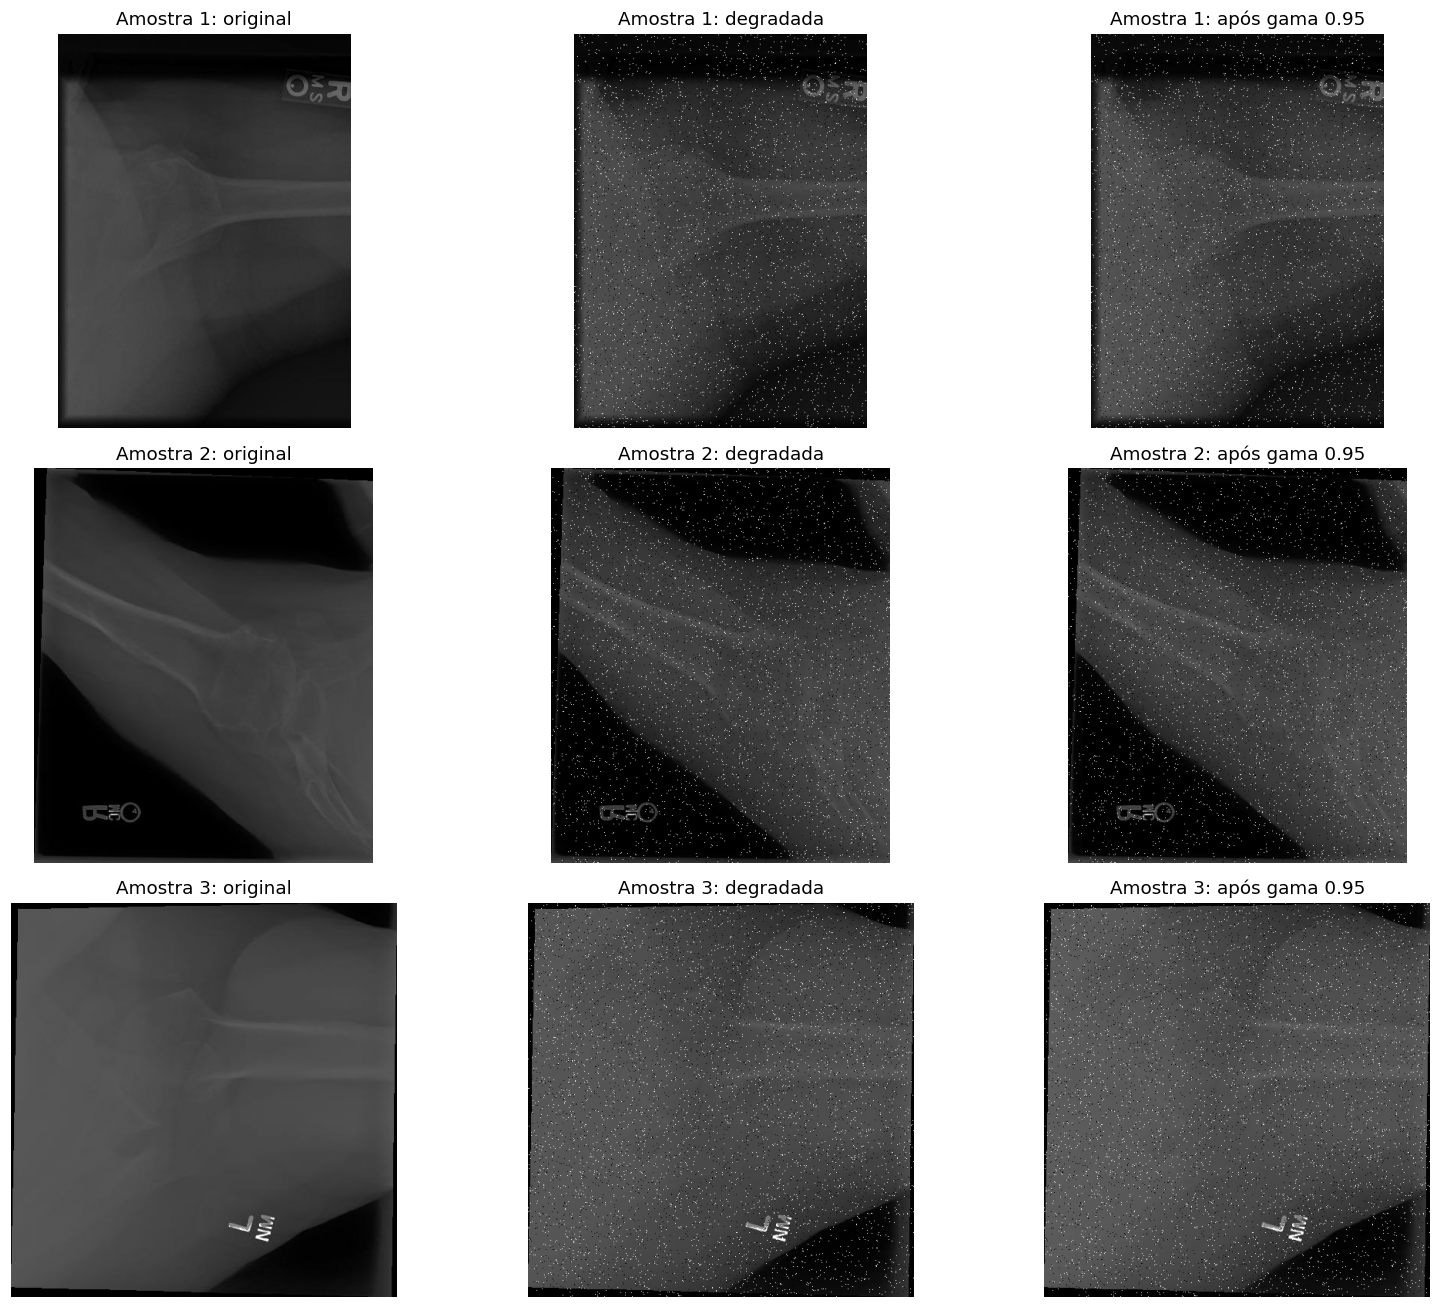

In [6]:
def clip_uint8(image):
    # Limita os valores dos pixels ao intervalo válido de 0 a 255
    # e converte a imagem para o formato uint8.
    return np.clip(np.rint(image), 0, 255).astype(np.uint8)


def add_salt_pepper_noise(image, amount=0.03, seed=2026):
    # Adiciona ruído sal e pimenta à imagem de forma controlada.
    # O ruído pode deixar pixels brancos (sal) ou pretos (pimenta).

    # Cria um gerador de números aleatórios utilizando uma semente fixa.
    generator = np.random.default_rng(seed)

    # Cria uma cópia da imagem original para preservar seus dados.
    noisy = image.copy()

    # Percorre todas as linhas da imagem.
    for row in range(image.shape[0]):

        for column in range(image.shape[1]):

            # Verifica se o pixel atual receberá ruído.
            if generator.random() < amount:

                # Define o pixel como preto (0) ou branco (255),
                # com 50% de chance para cada valor.
                noisy[row, column] = 0 if generator.random() < 0.5 else 255

    return noisy


def gamma_transform(image, gamma):
    # Aplica a correção gama manualmente em cada pixel da imagem.
    # Essa transformação modifica o brilho da imagem.

    output = np.zeros_like(image, dtype=np.uint8)

    for row in range(image.shape[0]):

        for column in range(image.shape[1]):

            # Normaliza o valor do pixel para o intervalo de 0 a 1.
            normalized = int(image[row, column]) / 255.0

            # Aplica a fórmula da correção gama.
            transformed = 255.0 * (normalized ** gamma)

            # Arredonda o resultado, limita-o entre 0 e 255
            # e armazena o valor no pixel de saída.
            output[row, column] = np.uint8(
                np.clip(round(transformed), 0, 255)
            )

    return output


# Aplica o ruído sal e pimenta em todas as imagens originais.
# Utiliza a quantidade e a semente definidas anteriormente.
degraded_images = [
    add_salt_pepper_noise(image, NOISE_AMOUNT, NOISE_SEED)
    for image in original_images
]


# Aplica a correção gama às imagens que já receberam ruído.
gamma_images = [
    gamma_transform(image, GAMMA_VALUE)
    for image in degraded_images
]


# Cria listas vazias para armazenar as imagens e seus títulos.
gamma_visual_images = []
gamma_visual_titles = []


# Percorre as imagens originais, degradadas e corrigidas simultaneamente.
# enumerate permite identificar cada amostra a partir da posição 1.
for position, (original, degraded, gamma_image) in enumerate(
    zip(original_images, degraded_images, gamma_images), start=1
):

    gamma_visual_images.extend([
        original,
        degraded,
        gamma_image
    ])

    gamma_visual_titles.extend([
        f"Amostra {position}: original",
        f"Amostra {position}: degradada",
        f"Amostra {position}: após gama {GAMMA_VALUE}",
    ])

show_image_grid(
    gamma_visual_images,
    gamma_visual_titles,
    rows=3,
    figsize=(15, 12),
)

In [7]:
def gaussian_kernel(size=5, sigma=1.0):
    # Cria uma máscara Gaussiana utilizada para suavizar a imagem.
    # size define o tamanho da máscara e sigma controla a intensidade da suavização.

    # Define a posição do centro da máscara.
    center = size // 2

    # Cria uma matriz preenchida inicialmente com zeros.
    kernel = np.zeros((size, size), dtype=np.float64)

    total = 0.0

    for row in range(size):

        for column in range(size):

            # Calcula a distância ao quadrado entre o ponto atual e o centro.
            distance_squared = (row - center) ** 2 + (column - center) ** 2

            # Calcula o valor Gaussiano para a posição atual.
            value = math.exp(-distance_squared / (2.0 * sigma ** 2))

            kernel[row, column] = value

            total += value

    return kernel / total

def convolve2d_manual(image, kernel):
    # Realiza a convolução 2D manualmente entre a imagem e uma máscara.
    # O padding com zeros é utilizado nas bordas da imagem.

    # Obtém a altura e a largura da máscara.
    kernel_height, kernel_width = kernel.shape

    # Calcula quantos pixels serão adicionados em cada borda.
    pad_height = kernel_height // 2
    pad_width = kernel_width // 2

    # Adiciona uma borda de zeros ao redor da imagem.
    # A imagem é convertida para float64 para aumentar a precisão dos cálculos.
    padded = np.pad(
        image.astype(np.float64),
        ((pad_height, pad_height), (pad_width, pad_width)),
        mode="constant",
    )

    # Cria uma matriz de saída com as mesmas dimensões da imagem original.
    output = np.zeros(image.shape, dtype=np.float64)

    for row in range(image.shape[0]):

        for column in range(image.shape[1]):

            accumulated = 0.0

            for kernel_row in range(kernel_height):

                for kernel_column in range(kernel_width):

                    # Multiplica o pixel da imagem pelo valor correspondente
                    # da máscara e adiciona o resultado ao acumulador.
                    accumulated += (
                        padded[row + kernel_row, column + kernel_column]
                        * kernel[kernel_row, kernel_column]
                    )

            # Armazena o resultado da convolução no pixel correspondente.
            output[row, column] = accumulated

    return output


def median_filter_manual(image, size=5):
    # Aplica manualmente o filtro da mediana.
    # Esse filtro é utilizado principalmente para reduzir ruídos impulsivos.

    # Calcula o número de pixels adicionados nas bordas.
    padding = size // 2

    # Calcula a posição do valor mediano dentro da lista ordenada.
    middle = (size * size) // 2

    # Adiciona uma borda de zeros ao redor da imagem.
    padded = np.pad(image, padding, mode="constant")

    output = np.zeros_like(image, dtype=np.uint8)

    for row in range(image.shape[0]):

        for column in range(image.shape[1]):

            # Cria uma lista para armazenar os pixels da vizinhança.
            neighborhood = []

            # Percorre as linhas da janela do filtro.
            for window_row in range(size):

                # Percorre as colunas da janela do filtro.
                for window_column in range(size):

                    # Adiciona o valor do pixel à lista da vizinhança.
                    neighborhood.append(
                        int(padded[row + window_row, column + window_column])
                    )

            neighborhood.sort()

            output[row, column] = neighborhood[middle]

    return output


# Cria uma máscara de média 3x3.
# Cada pixel possui o mesmo peso, igual a 1/9.
mean_kernel_3 = np.ones((3, 3), dtype=np.float64) / 9.0

# Cria uma máscara Gaussiana de tamanho 5x5 com sigma igual a 1.0.
gaussian_kernel_5 = gaussian_kernel(size=5, sigma=1.0)

print("Máscara Gaussiana 5x5:")

print(np.round(gaussian_kernel_5, 4))

Máscara Gaussiana 5x5:
[[0.003  0.0133 0.0219 0.0133 0.003 ]
 [0.0133 0.0596 0.0983 0.0596 0.0133]
 [0.0219 0.0983 0.1621 0.0983 0.0219]
 [0.0133 0.0596 0.0983 0.0596 0.0133]
 [0.003  0.0133 0.0219 0.0133 0.003 ]]


In [8]:
def unsharp_masking(image, amount=1.2):
    # Realça os detalhes da imagem utilizando a técnica Unsharp Masking.
    # A imagem original é comparada com uma versão suavizada para obter os detalhes.

    # Aplica um filtro de média 3x3 para suavizar a imagem.
    blurred = convolve2d_manual(image, mean_kernel_3)

    # Calcula os detalhes subtraindo a imagem suavizada da imagem original.
    detail = image.astype(np.float64) - blurred

    # Soma os detalhes realçados à imagem original.
    # clip_uint8 limita os valores entre 0 e 255 e converte para uint8.
    return clip_uint8(image.astype(np.float64) + amount * detail)


def high_boost(image, amount=1.15):
    # Realça os detalhes da imagem utilizando a técnica High-Boost.
    # A diferença entre a imagem e sua versão suavizada é utilizada
    # para aumentar a nitidez.

    # Aplica um filtro de média 3x3 para obter uma versão suavizada.
    blurred = convolve2d_manual(image, mean_kernel_3)

    # Obtém os detalhes presentes na imagem.
    detail = image.astype(np.float64) - blurred

    # Reforça os detalhes e adiciona-os novamente à imagem.
    return clip_uint8(image.astype(np.float64) + amount * detail)


def run_configuration(image):
    # Executa as duas configurações de processamento a partir
    # da mesma imagem que já recebeu a degradação.

    # Primeiro aplica a transformação gama para ajustar o brilho.
    point_operation = gamma_transform(image, GAMMA_VALUE)

    # Configuração A:
    # Aplica o filtro da mediana 5x5 para reduzir o ruído.
    median_smoothed = median_filter_manual(point_operation, size=5)

    # Realça os detalhes da imagem utilizando Unsharp Masking.
    configuration_a = unsharp_masking(median_smoothed, amount=1.2)

    # Configuração B:
    # Aplica a máscara Gaussiana 5x5 para suavizar a imagem.
    gaussian_smoothed = clip_uint8(
        convolve2d_manual(point_operation, gaussian_kernel_5)
    )

    # Realça os detalhes utilizando a técnica High-Boost.
    configuration_b = high_boost(gaussian_smoothed, amount=1.15)

    return {
        "gama": point_operation,
        "configuração A": configuration_a,
        "configuração B": configuration_b,
    }


# Inicia a contagem do tempo de processamento.
start_time = time.perf_counter()

# Executa as duas configurações para todas as imagens degradadas.
processed = [run_configuration(image) for image in degraded_images]

# Calcula o tempo total gasto no processamento.
elapsed = time.perf_counter() - start_time

# Exibe o tempo total utilizado para processar as três imagens.
print(f"Tempo total das duas configurações nas três imagens: {elapsed:.2f} s")

# Calcula e exibe o tempo médio de processamento por imagem.
print(f"Tempo médio por imagem: {elapsed / len(degraded_images):.2f} s")

Tempo total das duas configurações nas três imagens: 33.19 s
Tempo médio por imagem: 11.06 s


## 4. Resultados visuais

As figuras anteriores mostram, nas três radiografias, o efeito isolado da correção gama antes da filtragem. A figura abaixo mostra, para cada radiografia, a sequência original, degradada, configuração A e configuração B. Observe especialmente as regiões ósseas e os contornos: o resultado deve continuar sendo uma radiografia completa, com detalhes realçados dentro do contexto anatômico.


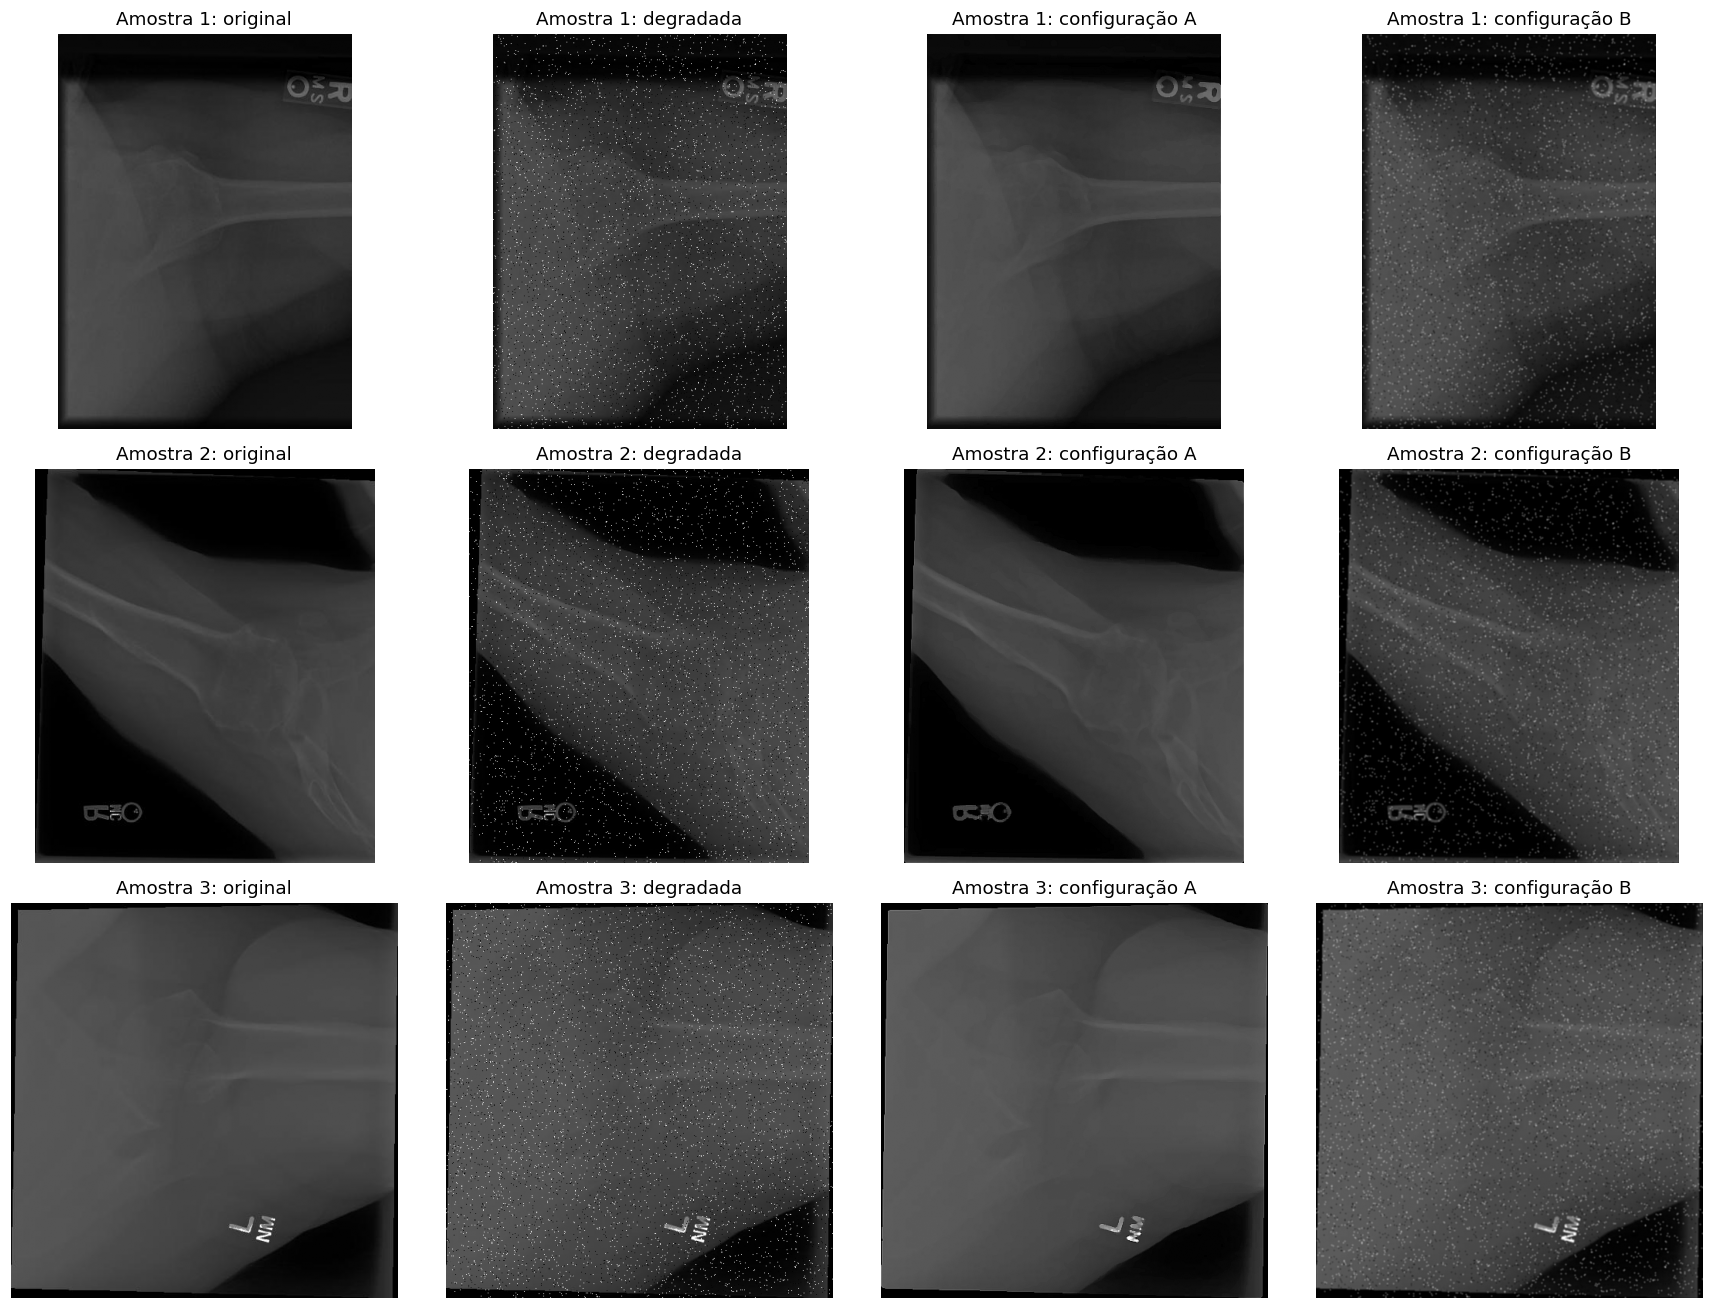

In [ ]:
# Cria uma lista vazia para armazenar todas as imagens e os titulos delas que serão exibidas.
visual_images = []

visual_titles = []

# Percorre simultaneamente as imagens originais, degradadas e processadas.
# enumerate começa a numeração das amostras em 1.
for position, (original, degraded, result) in enumerate(
    zip(original_images, degraded_images, processed), start=1
):

    # Adiciona à lista as quatro versões de cada amostra:
    # imagem original, imagem degradada, configuração A e configuração B.
    visual_images.extend([
        original,
        degraded,
        result["configuração A"],
        result["configuração B"],
    ])

    # Cria os títulos correspondentes para cada imagem.
    visual_titles.extend([
        f"Amostra {position}: original",
        f"Amostra {position}: degradada",
        f"Amostra {position}: configuração A",
        f"Amostra {position}: configuração B",
    ])

# Exibe todas as imagens utilizando a função show_image_grid.
# As imagens são organizadas em 3 linhas e o tamanho da figura é 16x12.
show_image_grid(visual_images, visual_titles, rows=3, figsize=(16, 12))

## 5. Métricas quantitativas

As duas métricas escolhidas são:

- **PSNR (Peak Signal-to-Noise Ratio):** transforma o erro quadrático médio em decibéis. Quanto maior, menor a diferença pixel a pixel em relação à imagem original;
- **SSIM (Structural Similarity):** compara luminância, contraste e estrutura local. Quanto mais próximo de 1, maior a similaridade estrutural.

As métricas são calculadas entre cada etapa e a imagem original limpa. Assim, conseguimos comparar a imagem degradada, o efeito isolado da gama e as configurações A/B sob a mesma referência. Elas são indicadores de processamento, não medidas de qualidade clínica; confirme antes da entrega que PSNR e SSIM estão entre as métricas apresentadas em aula.


In [ ]:
def mean_squared_error(reference, candidate):
    # Calcula o erro quadrático médio (MSE) entre duas imagens.
    # Quanto menor o MSE, menor é a diferença entre as imagens.

    # Converte as imagens para float64 e calcula a diferença entre
    # cada pixel da imagem de referência e da imagem processada.
    difference = reference.astype(np.float64) - candidate.astype(np.float64)

    # Eleva as diferenças ao quadrado e calcula a média de todos os pixels.
    return float(np.mean(difference ** 2))


def psnr(reference, candidate):
    # Calcula o PSNR (Peak Signal-to-Noise Ratio).
    # O PSNR mede a qualidade da imagem processada em relação à original.

    # Calcula primeiro o erro quadrático médio entre as imagens.
    error = mean_squared_error(reference, candidate)

    # Se o erro for zero, as imagens são idênticas.
    if error == 0:
        return float("inf")

    # Calcula o PSNR em decibéis (dB).
    # Quanto maior o PSNR, menor é a diferença entre as imagens.
    return 10.0 * math.log10((255.0 ** 2) / error)


def ssim_windowed(reference, candidate, window_size=8):
    # Calcula o SSIM (Structural Similarity Index) médio em pequenas
    # janelas da imagem, sem utilizar uma função pronta de biblioteca.

    # Converte as imagens para float64 para aumentar a precisão dos cálculos.
    reference = reference.astype(np.float64)
    candidate = candidate.astype(np.float64)

    # Constantes utilizadas na fórmula do SSIM.
    # Elas ajudam a evitar problemas quando os valores são muito próximos de zero.
    constant_1 = (0.01 * 255) ** 2
    constant_2 = (0.03 * 255) ** 2

    # Lista que armazenará o SSIM calculado para cada janela.
    scores = []

    # Percorre a imagem em blocos de tamanho definido por window_size.
    for row in range(0, reference.shape[0], window_size):
        for column in range(0, reference.shape[1], window_size):

            # Seleciona uma janela da imagem de referência.
            reference_window = reference[
                row:min(row + window_size, reference.shape[0]),
                column:min(column + window_size, reference.shape[1]),
            ]

            # Seleciona a mesma região na imagem processada.
            candidate_window = candidate[
                row:min(row + window_size, candidate.shape[0]),
                column:min(column + window_size, candidate.shape[1]),
            ]

            # Calcula a média dos pixels da janela de referência.
            mean_reference = reference_window.mean()

            # Calcula a média dos pixels da janela processada.
            mean_candidate = candidate_window.mean()

            # Calcula a variância da janela de referência.
            variance_reference = (
                (reference_window - mean_reference) ** 2
            ).mean()

            # Calcula a variância da janela processada.
            variance_candidate = (
                (candidate_window - mean_candidate) ** 2
            ).mean()

            # Calcula a covariância entre as duas janelas.
            covariance = (
                (reference_window - mean_reference)
                * (candidate_window - mean_candidate)
            ).mean()

            # Calcula o numerador da fórmula do SSIM.
            numerator = (
                (2 * mean_reference * mean_candidate + constant_1)
                * (2 * covariance + constant_2)
            )

            # Calcula o denominador da fórmula do SSIM.
            denominator = (
                (mean_reference ** 2 + mean_candidate ** 2 + constant_1)
                * (variance_reference + variance_candidate + constant_2)
            )

            # Calcula o SSIM da janela e adiciona o resultado à lista.
            scores.append(numerator / denominator)

    # Calcula a média dos valores de SSIM de todas as janelas.
    return float(np.mean(scores))


# Cria uma lista vazia para armazenar os resultados das métricas.
metric_rows = []

# Percorre as imagens originais, degradadas e processadas.
for position, (original, degraded, result) in enumerate(
    zip(original_images, degraded_images, processed), start=1
):

    # Define as diferentes etapas que serão comparadas com a imagem original.
    candidates = {
        "degradada": degraded,
        "após gama": result["gama"],
        "configuração A": result["configuração A"],
        "configuração B": result["configuração B"],
    }

    for stage, candidate in candidates.items():

        # Calcula e armazena as métricas PSNR e SSIM.
        metric_rows.append({
            "amostra": position,
            "etapa": stage,

            "PSNR (dB)": psnr(original, candidate),

            "SSIM": ssim_windowed(original, candidate),
        })


try:

    # Converte os resultados armazenados na lista em um DataFrame.
    metrics_table = pd.DataFrame(metric_rows)

    # Exibe a tabela arredondando os valores para quatro casas decimais.
    display(metrics_table.round(4))

# Caso o Pandas não esteja disponível, utiliza uma alternativa.
except NameError:

    # Percorre os resultados e imprime cada registro no terminal.
    for row in metric_rows:
        print(row)

,amostra,etapa,PSNR (dB),SSIM
0,1,degradada,19.7221,0.3420
1,1,após gama,19.6252,0.3350
2,1,configuração A,35.2540,0.9749
3,1,configuração B,26.7385,0.5380
4,2,degradada,19.4975,0.3513
5,2,após gama,19.4202,0.3462
6,2,configuração A,34.2004,0.9698
7,2,configuração B,26.6652,0.5086
8,3,degradada,20.2457,0.3114
9,3,após gama,20.0994,0.3063


,PSNR (dB),SSIM
etapa,,
degradada,19.8218,0.3349
após gama,19.7149,0.3291
configuração A,33.8985,0.9756
configuração B,26.7537,0.5296


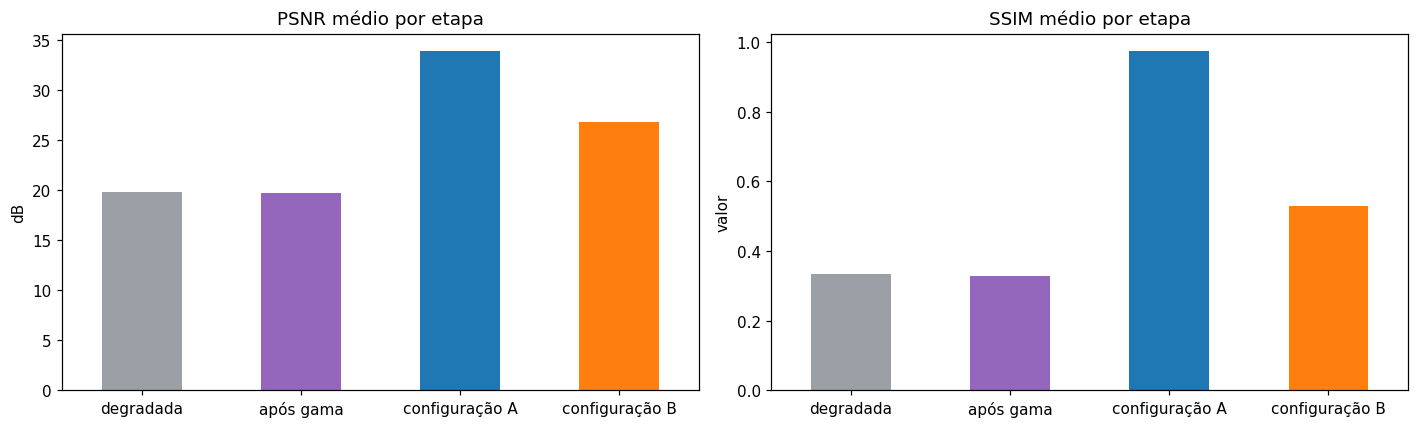

In [ ]:
# Cria uma tabela com os resultados das métricas e agrupa os dados pela etapa.
# Para cada etapa, calcula a média do PSNR e do SSIM das três amostras.
summary_table = pd.DataFrame(metric_rows).groupby(
    "etapa", sort=False
)[["PSNR (dB)", "SSIM"]].mean()

# Exibe a tabela de resultados arredondada para quatro casas decimais.
display(summary_table.round(4))


# Cria uma figura contendo dois gráficos lado a lado.
figure, axes = plt.subplots(1, 2, figsize=(13, 4))

# Define as cores que serão utilizadas nas barras dos gráficos.
colors = ["#9aa0a6", "#9467bd", "#1f77b4", "#ff7f0e"]


# Cria o gráfico de barras do PSNR médio de cada etapa.
summary_table["PSNR (dB)"].plot(
    kind="bar",
    ax=axes[0],
    color=colors
)

# Define o título do gráfico de PSNR.
axes[0].set_title("PSNR médio por etapa")

# Define o nome do eixo vertical.
axes[0].set_ylabel("dB")

# Remove o nome do eixo horizontal.
axes[0].set_xlabel("")

# Mantém os nomes das etapas na horizontal.
axes[0].tick_params(axis="x", rotation=0)


# Cria o gráfico de barras do SSIM médio de cada etapa.
summary_table["SSIM"].plot(
    kind="bar",
    ax=axes[1],
    color=colors
)

# Define o título do gráfico de SSIM.
axes[1].set_title("SSIM médio por etapa")

# Define o nome do eixo vertical.
axes[1].set_ylabel("valor")

# Remove o nome do eixo horizontal.
axes[1].set_xlabel("")

# Mantém os nomes das etapas na horizontal.
axes[1].tick_params(axis="x", rotation=0)


# Ajusta automaticamente os espaços entre os elementos dos gráficos.
plt.tight_layout()

# Exibe os dois gráficos na tela.
plt.show()

## 6. Análise e discussão

O esperado para esta experiência é que a imagem degradada apresente queda acentuada nas duas métricas devido aos impulsos pretos e brancos. A configuração A tende a obter o melhor resultado porque a mediana substitui cada pixel por um valor central da vizinhança, removendo sal-e-pimenta sem espalhar os outliers. O unsharp masking, aplicado depois, recupera contornos sem descartar a imagem completa.

Na configuração B, o Gaussiano distribui a influência de cada pixel pela vizinhança. Isso é adequado para ruído aproximadamente Gaussiano, mas é menos apropriado para impulsos: valores 0 e 255 podem contaminar vários pixels vizinhos. O high-boost pode tornar esse resíduo mais perceptível, além de acentuar halos em transições fortes.

Por isso, a escolha deve considerar o tipo de degradação: para o ruído sal-e-pimenta usado aqui, a configuração A é a alternativa tecnicamente mais adequada. Em imagens com ruído Gaussiano genuíno, a configuração B poderia ser reavaliada com uma intensidade menor de high-boost.


In [ ]:
# Cria um dicionário vazio para armazenar os melhores resultados
# encontrados para cada amostra.
best_by_sample = {}

# Percorre as três amostras, numeradas de 1 a 3.
for position in range(1, 4):

    # Seleciona apenas os resultados da amostra atual
    # referentes às configurações A e B.
    rows = [
        row for row in metric_rows
        if row["amostra"] == position
        and row["etapa"] in ("configuração A", "configuração B")
    ]

    # Encontra a configuração que apresentou o maior valor de SSIM.
    # O SSIM é utilizado para avaliar a similaridade estrutural.
    best_ssim = max(rows, key=lambda row: row["SSIM"])

    # Encontra a configuração que apresentou o maior valor de PSNR.
    # O PSNR mede a relação entre o sinal e o erro da imagem.
    best_psnr = max(rows, key=lambda row: row["PSNR (dB)"])

    # Armazena no dicionário qual configuração apresentou
    # o melhor SSIM e qual apresentou o melhor PSNR.
    best_by_sample[position] = (
        best_ssim["etapa"],
        best_psnr["etapa"]
    )

    # Exibe no terminal os resultados da amostra atual.
    print(
        f"Amostra {position}: melhor SSIM = {best_ssim['etapa']} "
        f"({best_ssim['SSIM']:.4f}); melhor PSNR = {best_psnr['etapa']} "
        f"({best_psnr['PSNR (dB)']:.4f} dB)."
    )


# Exibe uma observação final explicando o significado das duas métricas.
print(
    "\nLeitura final: o SSIM enfatiza a preservação estrutural, enquanto o PSNR "
    "penaliza diferenças de intensidade. A decisão final deve combinar métricas "
    "com a inspeção visual das estruturas anatômicas."
)

Amostra 1: melhor SSIM = configuração A (0.9749); melhor PSNR = configuração A (35.2540 dB).
Amostra 2: melhor SSIM = configuração A (0.9698); melhor PSNR = configuração A (34.2004 dB).
Amostra 3: melhor SSIM = configuração A (0.9820); melhor PSNR = configuração A (32.2410 dB).

Leitura final: o SSIM enfatiza a preservação estrutural, enquanto o PSNR penaliza diferenças de intensidade. A decisão final deve combinar métricas com a inspeção visual das estruturas anatômicas.


## 7. Conclusões e limitações

- A correção gama `0.95` clareia moderadamente as regiões escuras e foi aplicada antes da suavização.
- O ruído foi controlado em 3% dos pixels, com semente fixa, permitindo comparação justa.
- A mediana 5x5 foi mais adequada ao ruído impulsivo desta experiência; depois dela, o unsharp masking recuperou detalhes na imagem completa.
- O Gaussiano 5x5 produziu uma alternativa útil para discussão, mas espalhou parte dos impulsos e o high-boost reforçou alguns artefatos.
- As métricas foram calculadas em apenas três imagens de uma região anatômica. Elas não substituem avaliação radiológica, não validam uso clínico e podem favorecer uma configuração que se aproxima numericamente da imagem original, mesmo quando uma pequena diferença visual é desejável.
- O padding zero gera bordas artificiais nas extremidades; em uma aplicação real, seria necessário avaliar outro tratamento de borda.

Este notebook atende ao fluxo do enunciado e pode ser apresentado mostrando primeiro o problema, depois as decisões de parâmetros, os resultados visuais, a tabela de métricas e, por fim, as limitações.
